     0% poisoned  →  accuracy: 0.993
    10% poisoned  →  accuracy: 0.997
    20% poisoned  →  accuracy: 0.997
    30% poisoned  →  accuracy: 0.997
    40% poisoned  →  accuracy: 0.997
    50% poisoned  →  accuracy: 0.573


/tmp/ipykernel_15805/3667914245.py:218: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/label_poisoning_new.png'

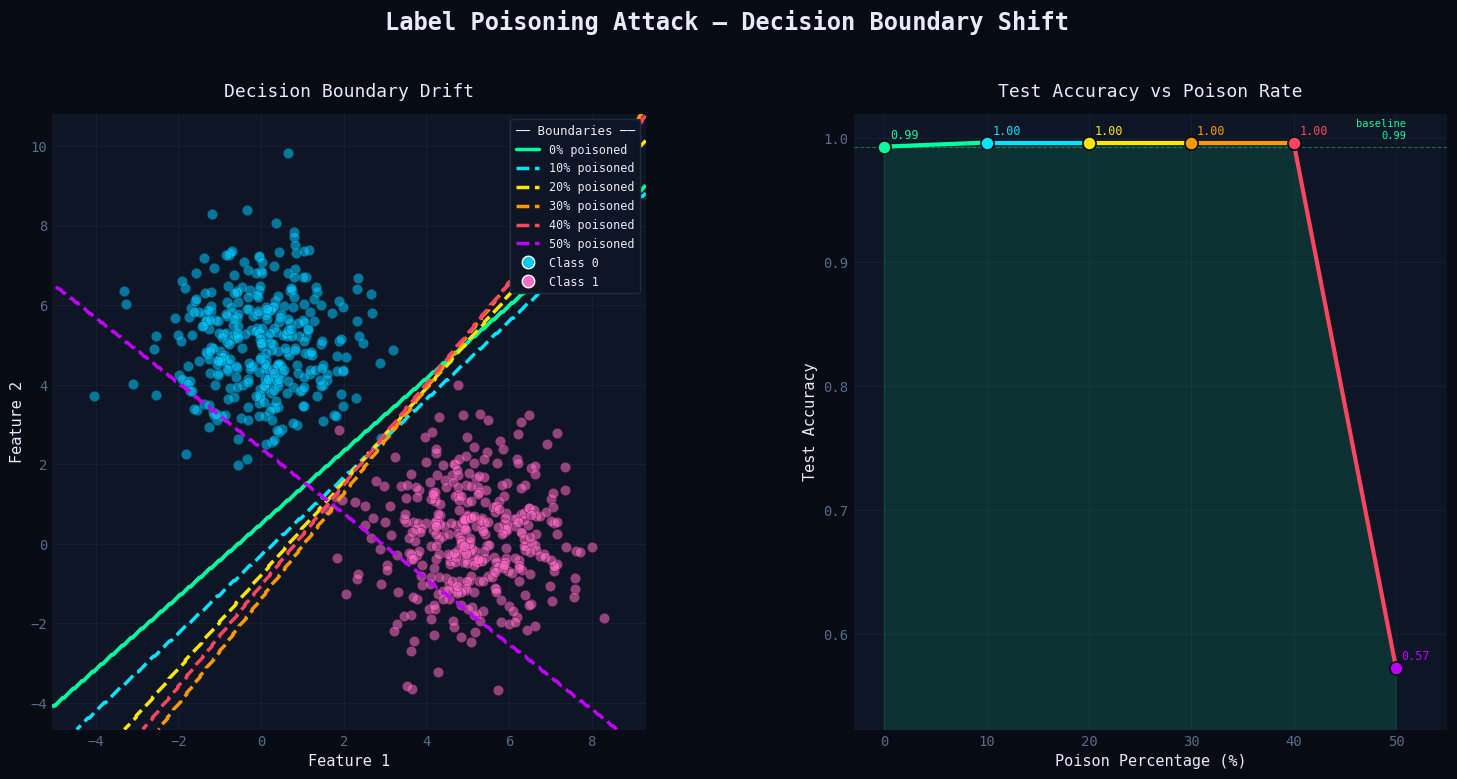

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# ── NEW Color palette ──────────────────────────────────────────────────────────
bg_dark        = "#070b14"        # near-black navy
panel_bg       = "#0e1525"        # card background
grid_col       = "#1e2d45"        # subtle grid lines
text_white     = "#e8eaf6"        # soft white text
text_muted     = "#546e8a"        # muted labels

# Data point colors
class0_col     = "#00c8ff"        # electric blue  → Class 0
class1_col     = "#ff6ec7"        # neon pink      → Class 1

# Boundary colors: clean → corrupted gradient
contour_colors = {
    0.0:  "#00ff9f",   # mint green   — clean baseline
    0.10: "#00e5ff",   # cyan         — 10%
    0.20: "#ffe600",   # yellow       — 20%
    0.30: "#ff9900",   # orange       — 30%
    0.40: "#ff4560",   # coral red    — 40%
    0.50: "#bf00ff",   # violet       — 50% fully corrupted
}
contour_linestyles = {
    0.0:  "solid",
    0.10: "dashed",
    0.20: "dashed",
    0.30: "dashed",
    0.40: "dashed",
    0.50: "dashed",
}

# ── Plot style ─────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor":  bg_dark,
    "axes.facecolor":    panel_bg,
    "axes.edgecolor":    grid_col,
    "axes.labelcolor":   text_white,
    "text.color":        text_white,
    "xtick.color":       text_muted,
    "ytick.color":       text_muted,
    "grid.color":        grid_col,
    "grid.alpha":        0.6,
    "legend.facecolor":  panel_bg,
    "legend.edgecolor":  grid_col,
    "legend.frameon":    True,
    "legend.framealpha": 1.0,
    "legend.labelcolor": text_white,
    "font.family":       "monospace",
})

SEED = 42
np.random.seed(SEED)

# ── Data ───────────────────────────────────────────────────────────────────────
X, y = make_blobs(
    n_samples=1000,
    centers=[(0, 5), (5, 0)],
    n_features=2,
    cluster_std=1.25,
    random_state=42,
)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# ── Mesh grid ──────────────────────────────────────────────────────────────────
margin = 1.0
xx, yy = np.meshgrid(
    np.linspace(X[:, 0].min() - margin, X[:, 0].max() + margin, 400),
    np.linspace(X[:, 1].min() - margin, X[:, 1].max() + margin, 400),
)
mesh_points = np.c_[xx.ravel(), yy.ravel()]

# ── Poisoning experiment ───────────────────────────────────────────────────────
poison_percentages       = [0.0, 0.10, 0.20, 0.30, 0.40, 0.50]
results                  = {"percentage": [], "model": [], "accuracy": []}
decision_boundaries_data = []

for pp in poison_percentages:
    y_poisoned = y_train.copy()
    if pp > 0:
        n_flip   = int(pp * len(y_train))
        flip_idx = np.random.choice(len(y_train), size=n_flip, replace=False)
        y_poisoned[flip_idx] = 1 - y_poisoned[flip_idx]

    model = LogisticRegression(random_state=SEED, max_iter=1000)
    model.fit(X_train, y_poisoned)
    acc = accuracy_score(y_test, model.predict(X_test))

    results["percentage"].append(pp)
    results["model"].append(model)
    results["accuracy"].append(acc)

    Z = model.predict(mesh_points).reshape(xx.shape)
    decision_boundaries_data.append({"percentage": pp, "Z": Z})
    print(f"  {pp*100:4.0f}% poisoned  →  accuracy: {acc:.3f}")

decision_boundaries_data.sort(key=lambda d: d["percentage"])

# ── Figure: 2 panels ──────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 8), facecolor=bg_dark)
fig.suptitle(
    "Label Poisoning Attack — Decision Boundary Shift",
    fontsize=17, color=text_white, fontweight="bold", y=1.01,
)

gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

# ════════════════════════════════════════════════════════════════════
# LEFT — Decision boundary plot
# ════════════════════════════════════════════════════════════════════
ax1.set_facecolor(panel_bg)
ax1.scatter(
    X_train[y_train == 0, 0], X_train[y_train == 0, 1],
    color=class0_col, edgecolors="#003344", s=55, alpha=0.55,
    linewidths=0.4, label="Class 0",
)
ax1.scatter(
    X_train[y_train == 1, 0], X_train[y_train == 1, 1],
    color=class1_col, edgecolors="#440033", s=55, alpha=0.55,
    linewidths=0.4, label="Class 1",
)

# Baseline (0%)
Z_baseline = results["model"][0].predict(mesh_points).reshape(xx.shape)
ax1.contour(xx, yy, Z_baseline, levels=[0.5],
            colors=[contour_colors[0.0]], linestyles=["solid"], linewidths=[2.8])

plotted = [0.0]
for data in decision_boundaries_data:
    pp = data["percentage"]
    if pp in [0.10, 0.20, 0.30, 0.40, 0.50]:
        ax1.contour(xx, yy, data["Z"], levels=[0.5],
                    colors=[contour_colors[pp]],
                    linestyles=[contour_linestyles[pp]],
                    linewidths=[2.5])
        plotted.append(pp)

ax1.set_title("Decision Boundary Drift", fontsize=13,
              color=text_white, pad=12)
ax1.set_xlabel("Feature 1", fontsize=11)
ax1.set_ylabel("Feature 2", fontsize=11)
ax1.set_xlim(xx.min(), xx.max())
ax1.set_ylim(yy.min(), yy.max())
ax1.grid(True, color=grid_col, linewidth=0.5, alpha=0.6)

# Legend
boundary_handles = [
    plt.Line2D([0], [0], color=contour_colors[pp], lw=2.5,
               linestyle=contour_linestyles[pp],
               label=f"{pp*100:.0f}% poisoned")
    for pp in sorted(plotted)
]
data_handles = [
    plt.Line2D([0], [0], marker="o", color="w", markersize=9,
               markerfacecolor=class0_col, linestyle="None", label="Class 0"),
    plt.Line2D([0], [0], marker="o", color="w", markersize=9,
               markerfacecolor=class1_col, linestyle="None", label="Class 1"),
]
ax1.legend(handles=boundary_handles + data_handles,
           title="── Boundaries ──", title_fontsize=9,
           fontsize=8.5, loc="upper right")

# ════════════════════════════════════════════════════════════════════
# RIGHT — Accuracy drop curve
# ════════════════════════════════════════════════════════════════════
ax2.set_facecolor(panel_bg)

pcts = [p * 100 for p in results["percentage"]]
accs = results["accuracy"]

# Shaded area under curve
ax2.fill_between(pcts, accs, alpha=0.12, color="#00ff9f")

# Gradient-colored line segments
from matplotlib.collections import LineCollection
points    = np.array([pcts, accs]).T.reshape(-1, 1, 2)
segments  = np.concatenate([points[:-1], points[1:]], axis=1)
grad_cols = ["#00ff9f", "#00e5ff", "#ffe600", "#ff9900", "#ff4560", "#bf00ff"]
lc = LineCollection(segments, colors=grad_cols, linewidths=3, zorder=3)
ax2.add_collection(lc)

# Markers
for i, (px, ay) in enumerate(zip(pcts, accs)):
    ax2.scatter(px, ay, color=grad_cols[i], s=90, zorder=5,
                edgecolors=bg_dark, linewidths=1.2)
    ax2.annotate(
        f"{ay:.2f}",
        xy=(px, ay), xytext=(4, 6),
        textcoords="offset points",
        fontsize=8.5, color=grad_cols[i], fontfamily="monospace",
    )

ax2.set_title("Test Accuracy vs Poison Rate", fontsize=13,
              color=text_white, pad=12)
ax2.set_xlabel("Poison Percentage (%)", fontsize=11)
ax2.set_ylabel("Test Accuracy", fontsize=11)
ax2.set_xlim(-3, 55)
ax2.set_ylim(min(accs) - 0.05, 1.02)
ax2.set_xticks([0, 10, 20, 30, 40, 50])
ax2.grid(True, color=grid_col, linewidth=0.5, alpha=0.6)

# Annotate baseline
ax2.axhline(accs[0], color="#00ff9f", linewidth=0.8,
            linestyle="--", alpha=0.4)
ax2.text(51, accs[0] + 0.005, f"baseline\n{accs[0]:.2f}",
         fontsize=7.5, color="#00ff9f", va="bottom", ha="right")

# ── Save ───────────────────────────────────────────────────────────────────────
plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/label_poisoning_new.png",
            dpi=150, bbox_inches="tight", facecolor=bg_dark)
plt.show()
print("Done — saved to label_poisoning_new.png")